In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import pyccl as ccl

import treecorr

import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

In [2]:
from halo_model.power_spectra.matter_power import MatterPower
from halo_model.power_spectra.angular_power import AngularPower
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config

In [3]:
#import ingredient models

from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010
from halo_model.halos.base.clump_mass_func.clump_mass_func import ClumpMassFunc

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.tinker2008 import MassFuncTinker2008

from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass


from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.halos.base.shmr.models.moster2013 import SMHRMoster2013
from halo_model.halos.base.shmr.models.Niemiec2022 import SMHRNiemiec2022

from halo_model.power_spectra.Pm_computer import Pm_computer


In [4]:
#set config & create ccl cosmology object
cfg = Config()

cfg.z_max = 2
cfg.z_min = 0
cfg.N_z = 6

# Cosmology parameters 

flat = True
H0 = cfg.cosmo.H0
Om0 = cfg.cosmo.Om0
Ob0 = cfg.cosmo.Ob0
sigma8 = cfg.cosmo.sigma8
ns = cfg.cosmo.ns

cosmo = ccl.Cosmology(Omega_c = Om0, Omega_b=Ob0, h=0.01*H0, sigma8=sigma8, n_s=ns)

In [5]:

c_smooth = ConcentrationNeto2007(cfg)
c_clump = ConcentrationPieri2009_clumps(c_smooth, d_vir=0.3)

mass_func = MassFuncTinker2008(cfg)

shmr_smooth = SMHRMoster2013(cfg, c_smooth)
shmr_clump = SMHRNiemiec2022(cfg, c_clump)

smooth_profile_dm = ProfileNFW(c_smooth, R_virSO(cfg))
clump_profile_dm = ProfileNFW(c_clump, R_virSO(cfg))

stellar_profile = ProfilePointMass()

bias = BiasTinker2010(cfg)

clump_distribution = ProfileNFW(c_smooth, R_virSO(cfg))


In [6]:
#computing model power spectra
z_grid = np.linspace(cfg.z_max, cfg.z_min, cfg.N_z) # from high redshift to low redshift so scale factor is monotonically increasing
k_grid = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Nz = len(z_grid)
Nk = len(k_grid)

P_grid = np.zeros((Nz, Nk))   # shape (z, k)
P_mod_grid = np.zeros((Nz, Nk)) 

for i,z in enumerate(z_grid):
    cfg_local = copy.deepcopy(cfg)
    cfg_local.z = z
    print(f"computing power spectrum at redshift {z}")
    
    # compute CDM power spectrum
    clump_mass_func = ClumpMassGiocoli2010(cfg_local)

    def w_smooth_dm(cosmo, M, z):
        return (1 - clump_mass_func.f(M)) * (1 - shmr_smooth(cosmo, M, z)) # contribution from dm in smooth
    def w_smooth_star(cosmo, M, z):
        return (1 - clump_mass_func.f(M)) * shmr_smooth(cosmo, M, z) # contribution from stars in smooth
    
    smooth_profile = CompositeProfile(
        smooth_profile_dm, stellar_profile,
        weights=[w_smooth_dm, w_smooth_star]
    )
    
    Pm = MatterPower(cfg_local, 
                    mass_func=mass_func, 
                    smooth_profile=smooth_profile, 
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile=clump_profile_dm, 
                    clump_distribution=clump_distribution)
        
    Pm_dict = Pm_computer(Pm, k_grid)
    Pm_tot = Pm_dict['P_tot']
    P_grid[i, :] = Pm_tot 
    

    # compute WDM power spectrum
    
    clump_mass_func_mod = ClumpMassGiocoli2010_mod(cfg_local)
    
    def w_smooth_dm(cosmo, M, z):
        return (1 - clump_mass_func_mod.f(M)) * (1 - shmr_smooth(cosmo, M, z)) 
    def w_smooth_star(cosmo, M, z):
        return shmr_smooth(cosmo, M, z) # contribution from stars in central
        
    
    smooth_profile = CompositeProfile(
        smooth_profile_dm, stellar_profile,
        weights=[w_smooth_dm, w_smooth_star]
    )

    Pm_mod = MatterPower(cfg_local, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func_mod, 
                 clump_profile=clump_profile_dm, 
                 clump_distribution=clump_distribution)
    
    Pm_mod_dict = Pm_computer(Pm_mod, k_grid)
    Pm_mod_tot = Pm_mod_dict['P_tot']
    P_mod_grid[i, :] = Pm_mod_tot
    
    
    plt.plot(k_grid, Pm_mod_tot/Pm_tot, label=f'z={z}')
    
plt.xscale("log")
plt.ylim(0.8, 1.1)
plt.xlim(np.min(k_grid), np.max(k_grid))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()
plt.show()

computing power spectrum at redshift 2.0


TypeError: MatterPower.__init__() missing 1 required positional argument: 'shmr'

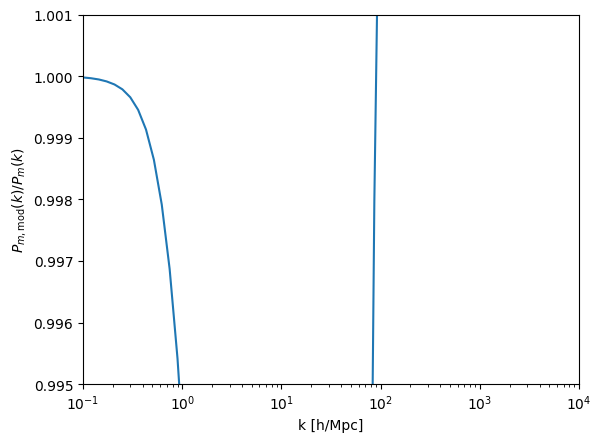

In [ ]:
plt.plot(k_grid, Pm_mod_tot/Pm_tot)
plt.xscale("log")
plt.ylim(0.995, 1.001)
plt.xlim(np.min(k_grid), np.max(k_grid))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.show()

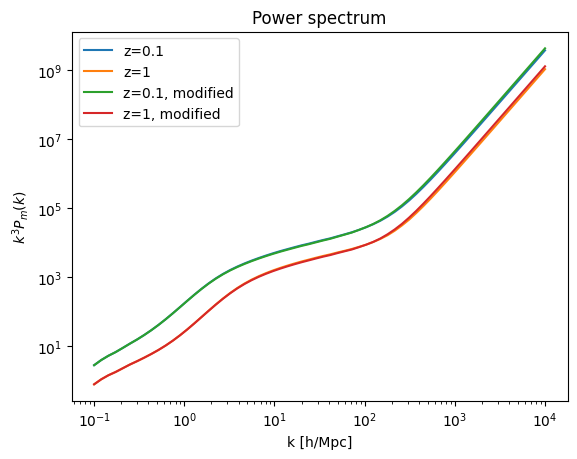

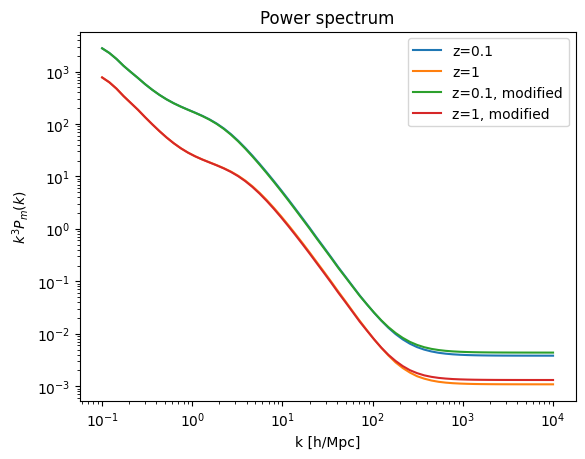

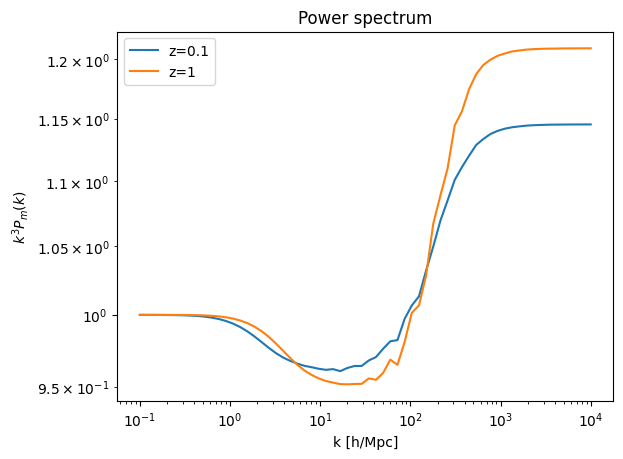

In [ ]:
# create ccl Pk2D objects for CDM and WDM power spectra

a_grid = 1/(1+z_grid)

Pk = ccl.Pk2D(
    a_arr=a_grid,
    lk_arr=np.log(k_grid),
    pk_arr=P_grid,
    is_logp=False  
)
Pk_mod = ccl.Pk2D(
    a_arr=a_grid,
    lk_arr=np.log(k_grid),
    pk_arr=P_mod_grid,
    is_logp=False  
)

#plot the power spectra at z = 0.1 and 1

plt.plot(k_grid, k_grid**3 *Pk(k_grid, 1/(1 + 0.1)), label='z=0.1')
plt.plot(k_grid, k_grid**3 *Pk(k_grid, 1/(1 + 1)), label='z=1')
plt.plot(k_grid, k_grid**3 *Pk_mod(k_grid, 1/(1 + 0.1)), label='z=0.1, modified')
plt.plot(k_grid, k_grid**3 *Pk_mod(k_grid, 1/(1 + 1)), label='z=1, modified')
plt.legend()

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$k^3 P_m(k)$')

plt.title("Power spectrum")
plt.loglog()
plt.show()


plt.plot(k_grid, Pk(k_grid, 1/(1 + 0.1)), label='z=0.1')
plt.plot(k_grid, Pk(k_grid, 1/(1 + 1)), label='z=1')
plt.plot(k_grid, Pk_mod(k_grid, 1/(1 + 0.1)), label='z=0.1, modified')
plt.plot(k_grid, Pk_mod(k_grid, 1/(1 + 1)), label='z=1, modified')
plt.legend()

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$k^3 P_m(k)$')

plt.title("Power spectrum")
plt.loglog()
plt.show()


plt.plot(k_grid, Pk_mod(k_grid, 1/(1 + 0.1)) / Pk(k_grid, 1/(1 + 0.1)), label='z=0.1')
plt.plot(k_grid, Pk_mod(k_grid, 1/(1 + 1)) / Pk(k_grid, 1/(1 + 1)), label='z=1')
plt.legend()

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$k^3 P_m(k)$')

plt.title("Power spectrum")
plt.loglog()
plt.show()

fraction of blue galaxies:  0.7813117875635198


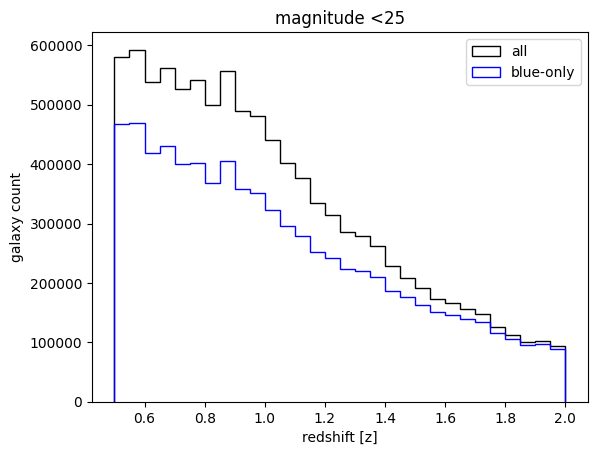

In [ ]:
# Load in source distribution from flagship

from astropy.io import fits
import numpy as np

# fits_file = fits.util.get_testdata_filepath("23586.fits")
hdul = fits.open("/home/milan/Desktop/thesis/flagship_sim/25224.fits")
hdr = hdul[1].header
data = hdul[1].data

z = data['true_redshift_gal']
flux = data['euclid_vis']
mag = -2.5 * np.log10(flux) - 48.6


# create a mask in redshift:
z_min = 0.5
z_max = 2
mask = np.where((z > z_min) & (z < z_max) & (mag < 25))

z = z[mask]
ra = data['ra_gal'][mask]
dec = data['dec_gal'][mask]

kappa = data['kappa'][mask]
gamma1 = data['gamma1'][mask]
gamma2 = data['gamma2'][mask]
eps1 = data['eps1_gal'][mask]
eps2 = data['eps2_gal'][mask]

u_flux_abs = data['cfht_u_abs'][mask]
r_flux_abs = data['subaru_r_abs'][mask]

z_edges = np.linspace(0.5, 2, 31)
plt.hist(z, bins=z_edges, histtype='step', label='all', color='black')

# now lets make cuts so we only select blue galaxies, for this we follow along 
# Euclid preparation:
# Calibrated intrinsic galaxy alignments in the Euclid Flagship simulation
# Euclid Collaboration: K. Hoffmann ....
# page 4 bottom right

h = 0.67
u_mag_abs = -2.5 * np.log10(u_flux_abs) - 48.6 + 5 * np.log10(h)
r_mag_abs = -2.5 * np.log10(r_flux_abs) - 48.6 + 5 * np.log10(h)

mask = (u_mag_abs - r_mag_abs < 1.32)

fraction_blue_galaxies = np.sum(mask) / len(mask)
print("fraction of blue galaxies: ", fraction_blue_galaxies)

z = z[mask]
ra = ra[mask]
dec = dec[mask]

kappa = kappa[mask]
gamma1 = gamma1[mask]
gamma2 = gamma2[mask]
eps1 = eps1[mask]
eps2 = eps2[mask]

z_edges = np.linspace(0.5, 2, 31)
plt.hist(z, bins=z_edges, histtype='step', label='blue-only', color='blue')
plt.xlabel('redshift [z]')
plt.ylabel('galaxy count')
plt.title('magnitude <25')
plt.legend()
plt.show()


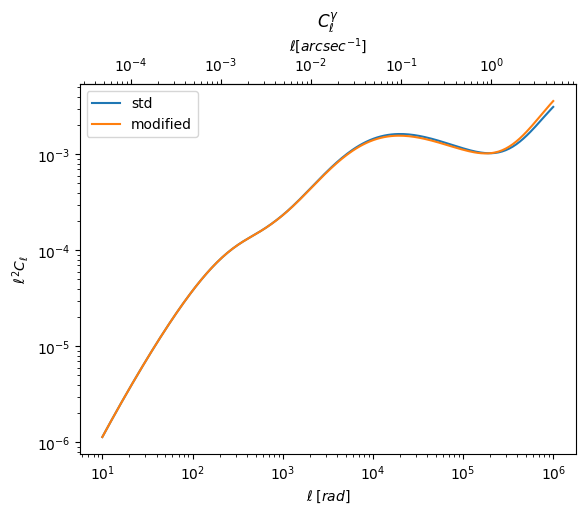

In [ ]:
# compute the Cls 

# source distribution follows the sources from the flagship simulation
z_edges = np.linspace(z_min, cfg.z_max, 10)
nzs = np.ndarray((z_edges.shape))

for i in range(len(z_edges) - 1):
    nzs[i] = np.sum(np.where((z<z_edges[i+1]) & (z>z_edges[i])))
    nzs /= len(z)

# define shear tracers
tr = ccl.WeakLensingTracer(cosmo=cosmo, dndz=(z_edges, nzs))

# compute C_ell
ell = np.logspace(1, 6, 256 + 1)
cl = ccl.angular_cl(cosmo, tracer1=tr, tracer2=tr, ell=ell, p_of_k_a=Pk)
cl_mod = ccl.angular_cl(cosmo, tracer1=tr, tracer2=tr, ell=ell, p_of_k_a=Pk_mod)


#plot the Cls

plt.plot(ell, ell**2*cl, label='std')
plt.plot(ell, ell**2*cl_mod, label='modified')

plt.title(r"$C_\ell^\gamma$")

plt.xlabel(r'$\ell \;[rad]$')
plt.ylabel(r'$\ell^2 C_\ell$')

def rad_to_arcsec_inv(x):
    return x / (180/np.pi * 3600)

def arcsec_to_rad_inv(x):
    return x / (np.pi/180 / 3600)

secax = plt.gca().secondary_xaxis('top', functions=(rad_to_arcsec_inv, arcsec_to_rad_inv))
secax.set_xlabel(r'$\ell [arcsec^{-1}]$')
plt.legend()
plt.xscale('log')
plt.yscale("log")
plt.show()

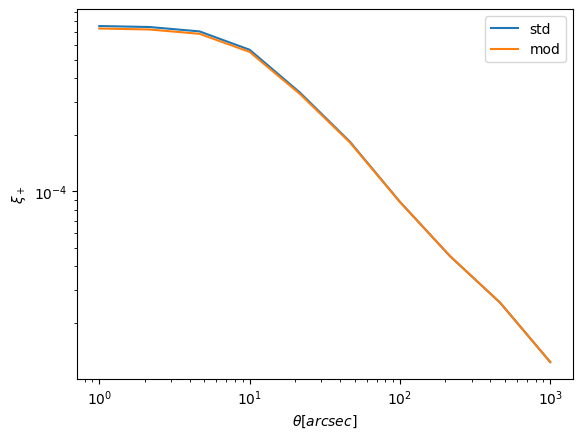

In [ ]:
#compute xi_p, xi_m & set theta range

tmin = 1
tmax = 1e3

nthet = 10
theta_deg = np.geomspace(tmin/3600, tmax/3600, nthet)

xi_plus = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_deg, type='GG+', method='bessel')
xi_plus_mod = ccl.correlation(cosmo, ell=ell, C_ell=cl_mod, theta=theta_deg, type='GG+', method='bessel')

# plot the xi_plus vals

plt.plot(theta_deg*3600, xi_plus, label='std')
plt.plot(theta_deg*3600, xi_plus_mod, label='mod')
plt.ylabel(r'$\xi_+$')
plt.xlabel(r'$\theta [arcsec]$')
plt.legend()
plt.loglog()
plt.show()


In [ ]:
#setup config for treecorr

#create theta bins
nbins = nthet

min_sep = 1/3600
max_sep = 1e3/3600

log_min = np.log10(min_sep)
log_max = np.log10(max_sep)
dlog = (log_max - log_min) / nbins

theta = theta_deg

config = {
    "nbins": nbins,
    "min_sep":  min_sep,
    "max_sep": max_sep,
    "sep_units": "degrees",
    "bin_type": "Log",

    # "min_rpar": PI_max,
    # "max_rpar": PI_max,

    "bin_slop": None, # None sets bin_slop = 0.1
    #"angle_slop": None,

    # "split_method": "mean", # How to split the cells in the tree when building the tree structure. 
    "metric": "Euclidean", #see metrics: https://rmjarvis.github.io/TreeCorr/_build/html/metric.html#metrics 
    "var_method": 'jackknife',
    "cross_patch_weight": 'simple',
}

In [ ]:
# get pairs function

def get_pairs(config, redshift_separation=0):
    mask1 = (z < 0.9 - redshift_separation/2)
    mask2 = (z > 0.9 + redshift_separation/2)
    print(np.sum(mask1)/len(mask1), np.sum(mask1), np.sum(mask2))

    cat1 = treecorr.Catalog(
        ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
    )

    cat2 = treecorr.Catalog(
        ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
    )

    nn = treecorr.NNCorrelation(config)
    nn.process(cat1, cat2)
    pairs_per_bin = nn.npairs

    return pairs_per_bin

pairs_per_bin = get_pairs(config, redshift_separation=0.05)



0.4090298370694683 3153609 4171184


In [ ]:
# plot pair count
number_density = len(z) / (10 * 60)**2

plt.step(theta_deg * 3600, pairs_per_bin, where='mid')
plt.legend()
plt.loglog()
plt.xlabel('theta [arcsec]')
plt.ylabel(r'pair count')
plt.title(f'redshift separation of {0.05}')
plt.show()

# plot pair count

# print(pairs_per_bin)

# plt.step(theta_deg * 3600, number_density, where='mid')
# plt.legend()
# plt.loglog()
# plt.xlabel('theta [arcsec]')
# plt.ylabel(r'pair count')
# plt.title(f'redshift separation of {0.05}')
# plt.show()

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
# get covariance function

def get_cov_delz(config, npatch, method='jackknife', including_shear=False, redshift_separation = 0):
    mask1 = (z < 0.9 - redshift_separation/2)
    mask2 = (z > 0.9 + redshift_separation/2)
    print(np.sum(mask1)/len(mask1))

    if including_shear:
        cat1 = treecorr.Catalog(
            ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
            k=kappa[mask1], g1=eps1[mask1] + gamma1[mask1], g2=eps2[mask1] +gamma2[mask1], npatch=npatch
        )

        cat2 = treecorr.Catalog(
            ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
            k=kappa[mask2], g1=eps1[mask2] + gamma1[mask2], g2=eps2[mask2] +gamma2[mask2], npatch=npatch
        )

    else:
        cat1 = treecorr.Catalog(
            ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
            k=kappa[mask1], g1=eps1[mask1], g2=eps2[mask1], npatch=npatch
        )

        cat2 = treecorr.Catalog(
            ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
            k=kappa[mask2], g1=eps1[mask2], g2=eps2[mask2], npatch=npatch
        )

    gg = treecorr.GGCorrelation(config)
    gg.process(cat1, cat2)
    cov = gg.estimate_cov(method=method, cross_patch_weight='simple')

    return cov

npatch = 30

redshift_separation = 0.05

IA_cov_delz = get_cov_delz(config, npatch=npatch, including_shear=False, redshift_separation=redshift_separation)
diag_IA_xip_delz = np.diag(IA_cov_delz)[:nbins]



0.4090298370694683


KeyboardInterrupt: 

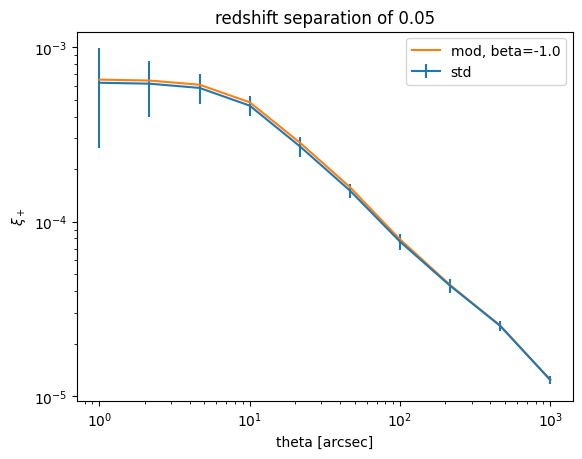

In [ ]:
# plot with error bars
xi_err =  np.sqrt(diag_IA_xip_delz)

plt.errorbar(theta_deg*3600, xi_plus, xi_err, label='std')
plt.plot(theta_deg*3600, xi_plus_mod, label=f'mod, beta={cfg.beta}')

plt.legend()
plt.loglog()
plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.show()

0.4090298370694683


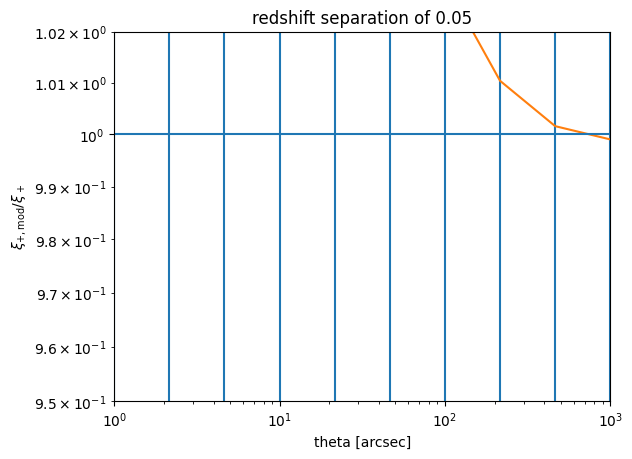

In [ ]:
# plot ratio with error bars
redshift_separation = 0.05

IA_cov_delz = get_cov_delz(config, npatch=npatch, including_shear=False, redshift_separation=redshift_separation)
diag_IA_xip_delz = np.diag(IA_cov_delz)[:nbins]

xi_err =  np.sqrt(diag_IA_xip_delz)

plt.errorbar(theta_deg*3600, xi_plus/xi_plus, xi_err/xi_plus)
plt.plot(theta_deg*3600, xi_plus_mod/xi_plus, label=f'mod, beta={cfg.beta}')

plt.loglog()
plt.xlim(1, 1e3)
plt.ylim(0.95, 1.02)
plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_{+, \mathrm{mod}}/\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.show()


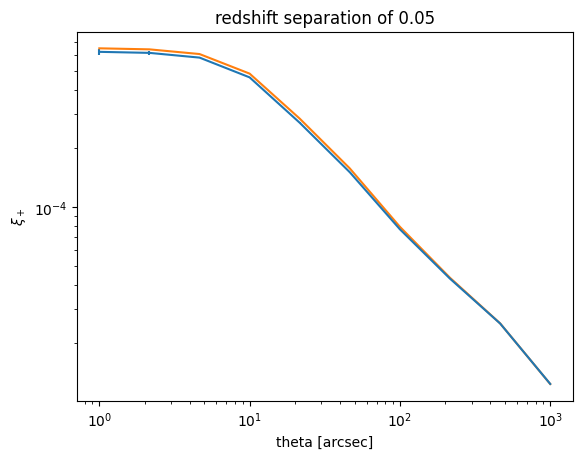

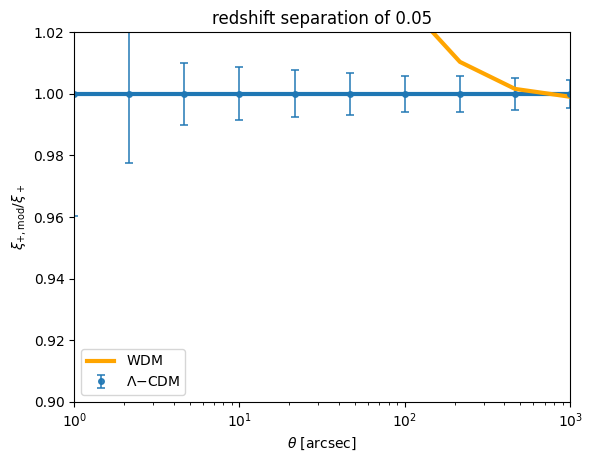

In [ ]:
# plot ratio with error bars with halfsky 
xi_err_halfsky = 1/np.sqrt(209) * xi_err

plt.errorbar(theta_deg*3600, xi_plus, xi_err_halfsky)
plt.plot(theta_deg*3600, xi_plus_mod, label=f'mod, beta={cfg.beta}')

plt.loglog()
plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.show()

plt.errorbar(
    theta_deg * 3600,
    xi_plus / xi_plus,
    yerr= xi_err_halfsky / xi_plus,
    fmt='o',                 # marker style
    markersize=4,
    color='tab:blue',
    ecolor='tab:blue',       # error bar color
    elinewidth=1.2,          # thickness of error bars
    capsize=3,               # little caps at the end
    capthick=1.2,
    linestyle='none',        # no connecting line
    alpha=0.9,
    label=r'$\Lambda\mathrm{-CDM}$'
)
plt.plot(theta_deg*3600, xi_plus/xi_plus, xi_err_halfsky/xi_plus, linewidth=3)
plt.plot(theta_deg*3600, xi_plus_mod/xi_plus, label=r'$\mathrm{WDM}$', color='orange', linewidth=3)
plt.legend()
plt.xlim(1, 1e3)
plt.ylim(0.9, 1.02)
plt.xscale('log')
plt.xlabel(r'$\theta$ [arcsec]')
plt.ylabel(r'$\xi_{+, \mathrm{mod}}/\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.savefig("plots_mock_measurements/mock_measurements.pdf")
plt.show()
